In [5]:
!pip install ptflops

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, 
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from ptflops import get_model_complexity_info

# 1. CONFIGURATION

In [6]:
MODEL_NAME = "MobileNetV2"
TEST_SIZE = 0.10  
RATIO_LABEL = "90:10"
INPUT_SIZE = (224, 224) 
BATCH_SIZE = 64
EPOCHS = 50

# 2. GPU SETUP

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPU: {torch.cuda.get_device_name(0)}")

Device: cuda | GPU: Tesla P100-PCIE-16GB


# 3. DATA & PATHS

In [9]:
CSV_FILE = "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv"
IMG_DIR = "/kaggle/input/datasets/deadcardassian/pm25vision/train/images"

df = pd.read_csv(CSV_FILE)
df.iloc[:, 1] = (df.iloc[:, 1] - df.iloc[:, 1].min()).clip(0, 5)

print("Class distribution in full dataset:")
print(df.iloc[:, 1].value_counts())

class PM25Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img_name = os.path.basename(str(self.df.iloc[idx, 0]))
        if not img_name.lower().endswith('.jpg'): img_name += '.jpg'
        img_path = os.path.join(IMG_DIR, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, int(self.df.iloc[idx, 1])

train_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Test transforms stay standard
test_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Class distribution in full dataset:
station_id
5    8293
0       3
2       2
Name: count, dtype: int64


# 4. MODEL & COMPLEXITY

# 5. DATA SPLITTING

In [10]:
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df.iloc[:,1], random_state=42)

# Calculate class weights based on Training set counts only
train_counts = train_df.iloc[:, 1].value_counts().to_dict()
# We use 1.0/count to calculate weights; rare classes get much higher weights
class_weights_dict = {i: 1.0 / train_counts.get(i, 1e-6) for i in range(6)}
sample_weights = [class_weights_dict[label] for label in train_df.iloc[:, 1]]

# WeightedRandomSampler forces rare classes into every batch
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

train_loader = DataLoader(PM25Dataset(train_df, train_transform), batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
test_loader = DataLoader(PM25Dataset(test_df, test_transform), batch_size=BATCH_SIZE, num_workers=2)

In [11]:
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5), # High dropout to prevent memorizing the rare samples
    nn.Linear(model.last_channel, 6)
)
model = model.to(device)

macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True, print_per_layer_stat=False)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 160MB/s]


In [12]:
loss_weight_tensor = torch.tensor([class_weights_dict[i] for i in range(6)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weight_tensor) 
optimizer = optim.Adam(model.parameters(), lr=5e-5) # Low learning rate for stability

# 5. TRAINING

In [13]:
start_train_wall = time.time()
for epoch in range(EPOCHS):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
train_wall_time = time.time() - start_train_wall

# 6. EVALUATION

In [16]:
model.eval()
y_true, y_pred, y_probs = [], [], []
start_test_wall = time.time()

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        y_true.extend(lbls.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_probs.extend(probs.cpu().numpy())
test_wall_time = time.time() - start_test_wall

# 7. METRICS & VISUALIZATION

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



--- MobileNetV2 90:10 Validated Results ---
Accuracy: 1.0000 | Balanced Accuracy: 1.0000
F1-Score: 1.0000 | ROC-AUC: 0.0000
Complexity: 319.03 MMac | Wall Time: Train 3137.45s


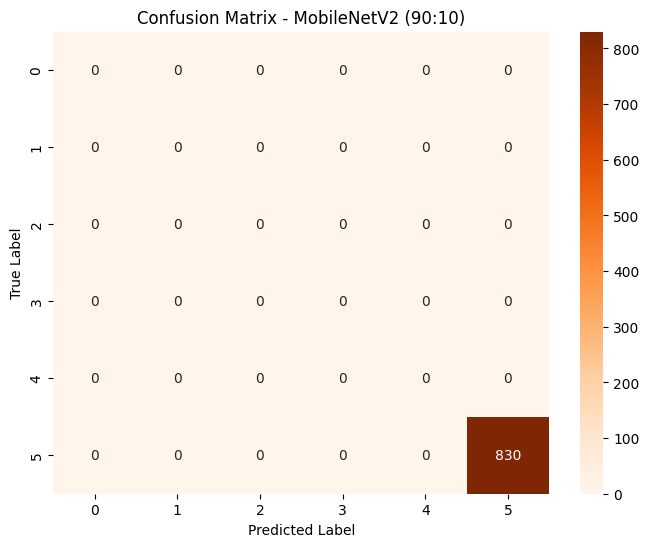

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


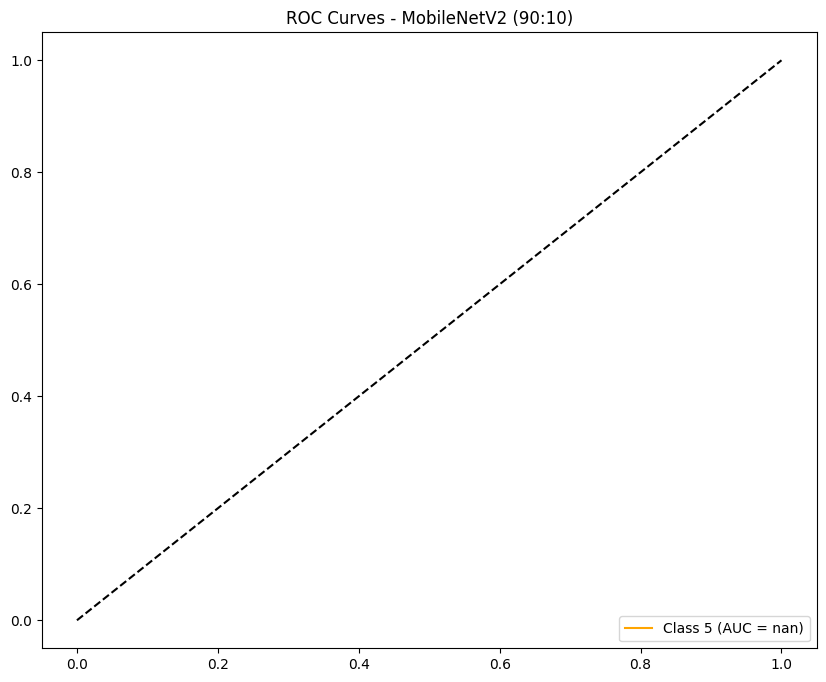

In [17]:
all_classes = [0, 1, 2, 3, 4, 5]
acc = accuracy_score(y_true, y_pred)
# balanced_accuracy_score is critical here; it treats every class as equally important
bal_acc = balanced_accuracy_score(y_true, y_pred) 
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

y_true_np = np.array(y_true)
y_probs_np = np.array(y_probs)
actual_classes_in_test = np.unique(y_true_np)

# Correct ROC-AUC for potentially missing classes in the test split
if len(actual_classes_in_test) > 1:
    auc_score = roc_auc_score(label_binarize(y_true_np, classes=all_classes), y_probs_np, multi_class='ovr', average='macro')
else:
    auc_score = 0.0

print(f"\n--- {MODEL_NAME} {RATIO_LABEL} Validated Results ---")
print(f"Accuracy: {acc:.4f} | Balanced Accuracy: {bal_acc:.4f}")
print(f"F1-Score: {f1:.4f} | ROC-AUC: {auc_score:.4f}")
print(f"Complexity: {macs} | Wall Time: Train {train_wall_time:.2f}s")

# --- 11. VISUALIZATION ---

cm = confusion_matrix(y_true, y_pred, labels=all_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=all_classes, yticklabels=all_classes)
plt.title(f"Confusion Matrix - {MODEL_NAME} ({RATIO_LABEL})")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Multi-class ROC Curve

y_true_bin = label_binarize(y_true, classes=all_classes)
plt.figure(figsize=(10,8))
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange']
for i, color in zip(range(len(all_classes)), colors):
    if np.sum(y_true_bin[:, i]) > 0: # Only plot if class actually exists in the test set
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_np[:, i])
        plt.plot(fpr, tpr, color=color, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.title(f"ROC Curves - {MODEL_NAME} ({RATIO_LABEL})")
plt.legend(loc="lower right")
plt.show()

# --- 12. CSV EXPORT ---
res_df = pd.DataFrame([{
    "Model": MODEL_NAME, "Split": RATIO_LABEL, "Accuracy": acc, "Balanced_Acc": bal_acc, 
    "F1": f1, "AUC": auc_score, "TrainTime": train_wall_time, "GFLOPs": macs
}])
res_df.to_csv(f"results_{MODEL_NAME}_{RATIO_LABEL.replace(':','_')}.csv", index=False)

In [19]:
# Check if all classes are actually in your test set
print("Classes in Test Set:")
print(test_df.iloc[:, 1].value_counts())

# Check for identical filenames in both sets (Leakage Check)
train_files = set(train_df.iloc[:, 0].values)
test_files = set(test_df.iloc[:, 0].values)
overlap = train_files.intersection(test_files)
print(f"Number of overlapping images: {len(overlap)}")

Classes in Test Set:
station_id
5    830
Name: count, dtype: int64
Number of overlapping images: 12
